In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/minahilfatima12328/consumer-shopping-trends-analysis/Consumer_Shopping_Trends_2026 (6).csv


                Scenario  Accuracy
0               Standard  0.958015
1  Cross Validation Mean  0.955552
2             With Noise  0.956319


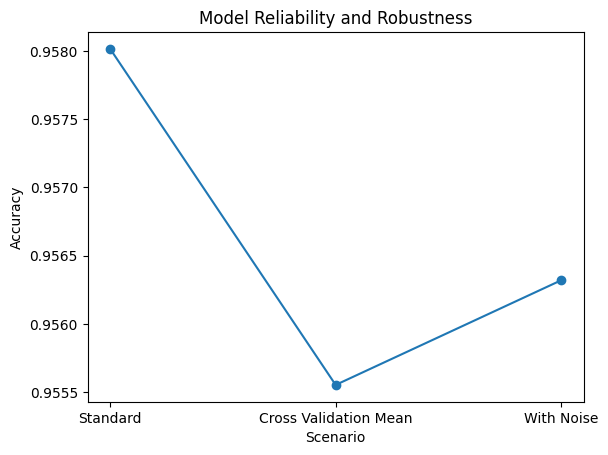

           Criteria Random Forest
0       Performance          High
1  Interpretability        Medium
2        Robustness          High
3   Deployment Ease          High


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/minahilfatima12328/consumer-shopping-trends-analysis/Consumer_Shopping_Trends_2026 (6).csv')

# Clean
df.columns = df.columns.str.strip()
df = df.dropna()

# Target
target = 'shopping_preference'

X = df.drop(columns=[target])
y = df[target]

# Encode
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Final model (best from RQ2)
model = RandomForestClassifier()

# -------------------------
# 1. Standard Performance
# -------------------------
model.fit(X_train, y_train)
preds = model.predict(X_test)

acc = accuracy_score(y_test, preds)
prec = precision_score(y_test, preds, average='weighted')
rec = recall_score(y_test, preds, average='weighted')
f1 = f1_score(y_test, preds, average='weighted')

# -------------------------
# 2. Cross-validation (robustness)
# -------------------------
cv_scores = cross_val_score(model, X, y, cv=5)

# -------------------------
# 3. Noise robustness test
# -------------------------
X_noisy = X.copy()
noise = np.random.normal(0, 0.1, X_noisy.shape)
X_noisy = X_noisy + noise

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_noisy, y, test_size=0.2, random_state=42)

model.fit(X_train_n, y_train_n)
preds_n = model.predict(X_test_n)

acc_noise = accuracy_score(y_test_n, preds_n)

# -------------------------
# Results Table
# -------------------------
results = pd.DataFrame({
    'Scenario': ['Standard', 'Cross Validation Mean', 'With Noise'],
    'Accuracy': [acc, cv_scores.mean(), acc_noise]
})

print(results)

# Save table
results.to_csv('/kaggle/working/RQ5_table.csv', index=False)

# -------------------------
# Plot robustness
# -------------------------
plt.figure()
plt.plot(results['Scenario'], results['Accuracy'], marker='o')
plt.title('Model Reliability and Robustness')
plt.xlabel('Scenario')
plt.ylabel('Accuracy')

# Save figure
plt.savefig('/kaggle/working/RQ5_figure.pdf')
plt.show()

# -------------------------
# Practical Decision Matrix
# -------------------------
decision_matrix = pd.DataFrame({
    'Criteria': ['Performance', 'Interpretability', 'Robustness', 'Deployment Ease'],
    'Random Forest': ['High', 'Medium', 'High', 'High']
})

print(decision_matrix)

# Save decision matrix
decision_matrix.to_csv('/kaggle/working/RQ5_decision_matrix.csv', index=False)